# H1 – Naive Baseline vs. Wettermodell

|                       |                                                                                                             |
|-----------------------|-------------------------------------------------------------------------------------------------------------|
| **Hypothese**         | Modelle mit Wetter- und Einstrahlungsdaten prognostizieren die PV-Produktion genauer als ein naiver Ansatz. |
| **Typ**               | Unterschiedshypothese / gerichtet                                                                           |
| **H₀**                | MAE(ML) ≥ MAE(naiv)                                                                                         |
| **H₁**                | MAE(ML) < MAE(naiv)                                                                                         |
| **Testverfahren**     | Paired t-Test (einseitig) auf per-Zeitschritt absolute Fehler                                               |
| **Signifikanzniveau** | α = 0.05                                                                                                    |

**Naive Baseline:** Saisonaler Stunden-Mittelwert (konditioniert auf Jahreszeit + Tagesstunde)

**ML-Modelle (BASE – nur Wetterfeatures, keine Zeitfeatures):**
- **Linear Regression BASE:** `ghi_cloudy_sky`, `clear_sky_index`, `temperature_2m`, `cloud_cover_low`
- **Random Forest BASE:** dieselben 4 Features

> Vorhersagen werden aus gespeicherten CSV-Dateien unter `results/` geladen.  
> Der Paired t-Test vergleicht für jeden Zeitschritt `t`: `d_t = |e_naiv_t| − |e_ML_t|`.  
> H₁ gilt als bestätigt wenn `mean(d) > 0` und `p < α`.

## 0 · Setup

In [ ]:
import sys
sys.path.insert(0, '../..')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src.evaluation.results import load_predictions

ALPHA = 0.05
P_NOM = 13_500.0

RESULTS_NAIVE = Path('../../results/00_naive_baseline')
RESULTS_LR    = Path('../../results/01_linear_regression')
RESULTS_RF    = Path('../../results/02_random_forest')

# Unified model order and colors — used in every plot
MODEL_ORDER  = ['Naive Baseline', 'LR BASE', 'RF BASE']
MODEL_COLORS = {
    'Naive Baseline': '#8172B2',
    'LR BASE':        '#4C72B0',
    'RF BASE':        '#DD8452',
}

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3})

## 1 · Vorhersagen laden

In [ ]:
naive_val = load_predictions(RESULTS_NAIVE, 'climatology_seasonal',   split='val')
lr_base   = load_predictions(RESULTS_LR,    'linear_regression_base',  split='val')
rf_base   = load_predictions(RESULTS_RF,    'random_forest_base',       split='val')

naive_test = load_predictions(RESULTS_NAIVE, 'climatology_seasonal',   split='test')
lr_base_t  = load_predictions(RESULTS_LR,    'linear_regression_base',  split='test')
rf_base_t  = load_predictions(RESULTS_RF,    'random_forest_base',       split='test')

# Val-Schnittmenge
idx = naive_val.index.intersection(lr_base.index).intersection(rf_base.index)
naive_val, lr_base, rf_base = naive_val.loc[idx], lr_base.loc[idx], rf_base.loc[idx]

# Test-Schnittmenge
idx_t = naive_test.index.intersection(lr_base_t.index).intersection(rf_base_t.index)
naive_test, lr_base_t, rf_base_t = naive_test.loc[idx_t], lr_base_t.loc[idx_t], rf_base_t.loc[idx_t]

print(f"Val-Set:  {idx.min().date()} → {idx.max().date()}  ({len(idx):,} Zeitschritte)")
print(f"Test-Set: {idx_t.min().date()} → {idx_t.max().date()}  ({len(idx_t):,} Zeitschritte)")


## 3 · Aggregierte Kennzahlen (Überblick)

Vergleich der aggregierten MAE-Werte auf Val- und Testset vor dem statistischen Test.

In [ ]:
def mae_of(df):
    return (df['y_true'] - df['y_pred']).abs().mean()

def rmse_of(df):
    return ((df['y_pred'] - df['y_true']) ** 2).mean() ** 0.5

def compute_metrics(df):
    ae = (df['y_pred'] - df['y_true']).abs()
    return {
        'MAE [W]':  ae.mean(),
        'RMSE [W]': ((df['y_pred'] - df['y_true']) ** 2).mean() ** 0.5,
        'nMAE':     ae.mean() / P_NOM,
        'R²':       1 - ((df['y_pred'] - df['y_true']) ** 2).sum()
                      / ((df['y_true'] - df['y_true'].mean()) ** 2).sum(),
    }

summary_df = pd.DataFrame({
    'Naive Baseline':  compute_metrics(naive_val),
    'LR BASE':         compute_metrics(lr_base),
    'RF BASE':         compute_metrics(rf_base),
}).T

display(summary_df.round(2))

## 4 · Paired t-Test

**Testprozedur:**  
Für jeden Zeitschritt `t` wird die Differenz der absoluten Fehler berechnet:
$$d_t = |e_{\text{naiv},t}| - |e_{\text{ML},t}|$$

- `d_t > 0` → ML ist für Zeitschritt `t` besser  
- `d_t < 0` → Naive ist für Zeitschritt `t` besser  

**Einseitiger t-Test:** H₁: `mean(d) > 0`  
Entscheidungsmetrik: **MAE** — RMSE dient als Referenz.

In [ ]:
def paired_ttest(naive_df, ml_df, model_name):
    """Paired t-Test: H1: mean(|e_naive| - |e_ML|) > 0"""
    ae_naive = (naive_df['y_true'] - naive_df['y_pred']).abs()
    ae_ml    = (ml_df['y_true']    - ml_df['y_pred']).abs()
    d        = ae_naive - ae_ml  # positiv = ML besser

    t_stat, p_two = stats.ttest_1samp(d.dropna(), popmean=0)
    p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2

    return {
        'Modell':          model_name,
        'n':               int(d.notna().sum()),
        'MAE naiv [W]':    ae_naive.mean(),
        'MAE ML [W]':      ae_ml.mean(),
        'RMSE naiv [W]':   rmse_of(naive_df),
        'RMSE ML [W]':     rmse_of(ml_df),
        'mean(d) [W]':     d.mean(),
        't-Statistik':     t_stat,
        'p-Wert (1-s.)':   p_one,
        f'H₁ (α={ALPHA})': p_one < ALPHA,
    }, d


ttest_rows, diffs = [], {}

for model_name, ml_df in [
    ('Linear Regression BASE', lr_base),
    ('Random Forest BASE',     rf_base),
]:
    row, d = paired_ttest(naive_val, ml_df, model_name)
    ttest_rows.append(row)
    diffs[model_name] = d

ttest_df = pd.DataFrame(ttest_rows).set_index('Modell')
display(ttest_df.round(4))

## 5 · Interpretation des t-Tests

In [ ]:
print(f"{'='*65}")
print(f"  H1-TEST: Paired t-Test (α = {ALPHA}, einseitig, Val-Set)")
print(f"{'='*65}")

for model_name in ['Linear Regression BASE', 'Random Forest BASE']:
    row       = ttest_df.loc[model_name]
    confirmed = row[f'H₁ (α={ALPHA})']
    mean_d    = row['mean(d) [W]']
    p         = row['p-Wert (1-s.)']
    mae_naive = row['MAE naiv [W]']
    mae_ml    = row['MAE ML [W]']
    rmse_naive = row['RMSE naiv [W]']
    rmse_ml    = row['RMSE ML [W]']

    direction = 'besser' if mean_d > 0 else 'SCHLECHTER'
    verdict   = '✓ H₁ BESTÄTIGT' if confirmed else '✗ H₁ ABGELEHNT'

    print(f"\n  {model_name}")
    print(f"    MAE:  {mae_naive:.1f} W → {mae_ml:.1f} W  (mean(d) = {mean_d:+.1f} W, ML {direction})")
    print(f"    RMSE: {rmse_naive:.1f} W → {rmse_ml:.1f} W  (Referenz)")
    print(f"    p-Wert = {p:.4f}  → {verdict}")

print(f"\n{'='*65}")

## 6 · Visualisierung

### 6.1 – MAE-Vergleich (Val & Test)

In [ ]:
MODEL_DATA = {
    'Naive Baseline': {'val': naive_val,  'test': naive_test},
    'LR BASE':        {'val': lr_base,    'test': lr_base_t},
    'RF BASE':        {'val': rf_base,    'test': rf_base_t},
}

# Naive-Referenzlinie: Mittelwert aus Val- und Test-MAE / RMSE
naive_mae_ref  = (mae_of(naive_val)  + mae_of(naive_test))  / 2
naive_rmse_ref = (rmse_of(naive_val) + rmse_of(naive_test)) / 2

x = np.arange(len(MODEL_ORDER))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

for ax, metric_fn, ref, title, ylabel in [
    (axes[0], mae_of,  naive_mae_ref,  'MAE – Val & Test  ★ Entscheidungsmetrik', 'MAE [W]'),
    (axes[1], rmse_of, naive_rmse_ref, 'RMSE – Val & Test  (Referenz)',            'RMSE [W]'),
]:
    ax.set_facecolor('white')
    for i, (split, hatch, label_suffix) in enumerate([('val', '', 'Validierung'), ('test', '//', 'Test')]):
        values = [metric_fn(MODEL_DATA[m][split]) for m in MODEL_ORDER]
        colors = [MODEL_COLORS[m] for m in MODEL_ORDER]
        offset = (i - 0.5) * width
        bars = ax.bar(x + offset, values, width, label=label_suffix,
                      color=colors, edgecolor='white', linewidth=1.0,
                      hatch=hatch, alpha=0.85 if split == 'val' else 0.65)
        ax.bar_label(bars, fmt='%.0f W', padding=4, fontsize=9)

    ax.axhline(ref, color='red', linestyle='--', linewidth=1.8,
               label=f'Naive Ø ({ref:.0f} W)', alpha=0.9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER)
    ax.set_ylim(0, max(metric_fn(MODEL_DATA[m][s]) for m in MODEL_ORDER for s in ('val','test')) * 1.3)
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(axis='y', linestyle=':', alpha=0.4, color='gray')

fig.suptitle('H1: Naive Baseline vs. Wettermodelle (BASE)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 6.2 – Verteilung der Fehlerdifferenzen `d_t = |e_naiv| − |e_ML|`

Positive Werte bedeuten: ML besser als Naive für diesen Zeitschritt.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (model_name, color) in zip(axes, [
    ('Linear Regression BASE', '#4C72B0'),
    ('Random Forest BASE',     '#DD8452'),
]):
    d = diffs[model_name].dropna()
    mean_d = d.mean()
    pct_better = (d > 0).mean() * 100

    ax.hist(d, bins=80, color=color, edgecolor='white', linewidth=0.4, alpha=0.75)
    ax.axvline(0,      color='white', lw=1.5, ls='--', label='d = 0')
    ax.axvline(mean_d, color='red',   lw=2.0, ls='-',
               label=f'mean(d) = {mean_d:+.1f} W')
    ax.set_title(f'{model_name}\nML besser: {pct_better:.1f}% der Zeitschritte', fontsize=10)
    ax.set_xlabel('d_t = |e_naiv| − |e_ML|  [W]')
    ax.set_ylabel('Häufigkeit')
    ax.legend(fontsize=9)

fig.suptitle('H1: Verteilung der Fehlerdifferenzen  (positiv = ML besser, Val-Set)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
SEASON_MAP = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Frühling', 4: 'Frühling', 5: 'Frühling',
              6: 'Sommer', 7: 'Sommer', 8: 'Sommer',
              9: 'Herbst', 10: 'Herbst', 11: 'Herbst'}
SEASON_ORDER = ['Winter', 'Frühling', 'Sommer', 'Herbst']

rows_season = []
for model_name in MODEL_ORDER:
    df = MODEL_DATA[model_name]
    season = df.index.month.map(SEASON_MAP)
    for s in SEASON_ORDER:
        sub = df[season == s]
        if sub.empty:
            continue
        rows_season.append({
            'Jahreszeit': s,
            'Modell':     model_name,
            'MAE [W]':    (sub['y_true'] - sub['y_pred']).abs().mean(),
        })

seasons_present = [s for s in SEASON_ORDER if s in pd.DataFrame(rows_season)['Jahreszeit'].values]
pivot = (pd.DataFrame(rows_season)
         .pivot(index='Jahreszeit', columns='Modell', values='MAE [W]')
         .loc[seasons_present, MODEL_ORDER])   # enforce unified order

display(pivot.round(1))

colors = [MODEL_COLORS[m] for m in MODEL_ORDER]
ax = pivot.plot(kind='bar', figsize=(10, 5), rot=0, color=colors,
                edgecolor='white', linewidth=1.0)
ax.set_title('H1: MAE nach Jahreszeit – Val-Set', fontsize=12, fontweight='bold')
ax.set_ylabel('MAE [W]')
ax.set_xlabel('')
ax.legend(title='Modell', fontsize=9)
for bar in ax.patches:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 2,
                f'{h:.0f}', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

## 7 · Saisonale Aufschlüsselung (Testset)

Aufschlüsselung nach Jahreszeit zeigt, in welchen Perioden die Wettermodelle
der Naive-Baseline über- oder unterlegen sind.

## 8 · Fazit

### Ergebnis des Paired t-Tests (Testset, α = 0.05)

In [ ]:
print("=" * 70)
print("FAZIT – H1: Naive Baseline vs. Wettermodelle (BASE)")
print("=" * 70)

for model_name in ['Linear Regression BASE', 'Random Forest BASE']:
    row       = ttest_df.loc[model_name]
    confirmed = row[f'H₁ (α={ALPHA})']
    mae_naive = row['MAE naiv [W]']
    mae_ml    = row['MAE ML [W]']
    rmse_naive = row['RMSE naiv [W]']
    rmse_ml    = row['RMSE ML [W]']
    mean_d    = row['mean(d) [W]']
    p         = row['p-Wert (1-s.)']
    delta_pct = (mae_ml - mae_naive) / mae_naive * 100
    verdict   = 'ABGELEHNT ✗' if not confirmed else 'BESTÄTIGT ✓'

    print(f"\n  {model_name}")
    print(f"    MAE:  {mae_naive:.1f} W → {mae_ml:.1f} W  ({delta_pct:+.1f}%)")
    print(f"    RMSE: {rmse_naive:.1f} W → {rmse_ml:.1f} W  (Referenz)")
    print(f"    mean(d_t) = {mean_d:+.1f} W   p = {p:.4f}   → H₁ {verdict}")

print()
print("-" * 70)
print("""
Interpretation:
  H₁ wird für beide BASE-Modelle abgelehnt. Wetterfeatures allein
  (ohne Zeitkontext) reichen nicht aus, um die Naive Baseline zu schlagen.

  Die Naive Baseline nutzt implizit Tageszeit & Saisonalität (saisonale
  Stunden-Mittelwerte) — den dominanten Faktor für PV-Produktion.
  BASE-Modelle ohne Zeitfeatures können diesen Vorteil nicht kompensieren.

  → Ob ML-Modelle die Naive Baseline schlagen, wenn Zeitfeatures
    hinzukommen, wird in H2 untersucht.
""")
print("=" * 70)

## 0 · Setup

In [1]:
import sys
sys.path.insert(0, '../..')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src.evaluation.results import load_predictions

ALPHA = 0.05
P_NOM = 13_500.0

RESULTS_NAIVE = Path('../../results/00_naive_baseline')
RESULTS_LR    = Path('../../results/01_linear_regression')
RESULTS_RF    = Path('../../results/02_random_forest')

# Unified model order and colors — used in every plot
MODEL_ORDER  = ['Naive Baseline', 'LR BASE', 'RF BASE']
MODEL_COLORS = {
    'Naive Baseline': '#8172B2',
    'LR BASE':        '#4C72B0',
    'RF BASE':        '#DD8452',
}

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3})

## 1 · Vorhersagen laden

In [2]:
naive_val = load_predictions(RESULTS_NAIVE, 'climatology_seasonal',   split='val')
lr_base   = load_predictions(RESULTS_LR,    'linear_regression_base',  split='val')
rf_base   = load_predictions(RESULTS_RF,    'random_forest_base',       split='val')

naive_test = load_predictions(RESULTS_NAIVE, 'climatology_seasonal',   split='test')
lr_base_t  = load_predictions(RESULTS_LR,    'linear_regression_base',  split='test')
rf_base_t  = load_predictions(RESULTS_RF,    'random_forest_base',       split='test')

# Val-Schnittmenge
idx = naive_val.index.intersection(lr_base.index).intersection(rf_base.index)
naive_val, lr_base, rf_base = naive_val.loc[idx], lr_base.loc[idx], rf_base.loc[idx]

# Test-Schnittmenge
idx_t = naive_test.index.intersection(lr_base_t.index).intersection(rf_base_t.index)
naive_test, lr_base_t, rf_base_t = naive_test.loc[idx_t], lr_base_t.loc[idx_t], rf_base_t.loc[idx_t]

print(f"Val-Set:  {idx.min().date()} → {idx.max().date()}  ({len(idx):,} Zeitschritte)")
print(f"Test-Set: {idx_t.min().date()} → {idx_t.max().date()}  ({len(idx_t):,} Zeitschritte)")


Val-Set:  2024-06-14 → 2024-12-15  (17,643 Zeitschritte)
Test-Set: 2024-12-15 → 2025-06-16  (17,643 Zeitschritte)


## 3 · Aggregierte Kennzahlen (Überblick)

Vergleich der aggregierten MAE-Werte auf Val- und Testset vor dem statistischen Test.

In [3]:
def mae_of(df):
    return (df['y_true'] - df['y_pred']).abs().mean()

def rmse_of(df):
    return ((df['y_pred'] - df['y_true']) ** 2).mean() ** 0.5

def compute_metrics(df):
    ae = (df['y_pred'] - df['y_true']).abs()
    return {
        'MAE [W]':  ae.mean(),
        'RMSE [W]': ((df['y_pred'] - df['y_true']) ** 2).mean() ** 0.5,
        'nMAE':     ae.mean() / P_NOM,
        'R²':       1 - ((df['y_pred'] - df['y_true']) ** 2).sum()
                      / ((df['y_true'] - df['y_true'].mean()) ** 2).sum(),
    }

summary_df = pd.DataFrame({
    'Naive Baseline':  compute_metrics(naive_val),
    'LR BASE':         compute_metrics(lr_base),
    'RF BASE':         compute_metrics(rf_base),
}).T

display(summary_df.round(2))

,MAE [W],RMSE [W],nMAE,R²
Naive Baseline,184.51,433.28,0.01,0.56
LR BASE,242.81,478.95,0.02,0.46
RF BASE,239.32,489.04,0.02,0.43


## 4 · Paired t-Test

**Testprozedur:**  
Für jeden Zeitschritt `t` wird die Differenz der absoluten Fehler berechnet:
$$d_t = |e_{\text{naiv},t}| - |e_{\text{ML},t}|$$

- `d_t > 0` → ML ist für Zeitschritt `t` besser  
- `d_t < 0` → Naive ist für Zeitschritt `t` besser  

**Einseitiger t-Test:** H₁: `mean(d) > 0`  
Entscheidungsmetrik: **MAE** — RMSE dient als Referenz.

In [4]:
def paired_ttest(naive_df, ml_df, model_name):
    """Paired t-Test: H1: mean(|e_naive| - |e_ML|) > 0"""
    ae_naive = (naive_df['y_true'] - naive_df['y_pred']).abs()
    ae_ml    = (ml_df['y_true']    - ml_df['y_pred']).abs()
    d        = ae_naive - ae_ml  # positiv = ML besser

    t_stat, p_two = stats.ttest_1samp(d.dropna(), popmean=0)
    p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2

    return {
        'Modell':          model_name,
        'n':               int(d.notna().sum()),
        'MAE naiv [W]':    ae_naive.mean(),
        'MAE ML [W]':      ae_ml.mean(),
        'RMSE naiv [W]':   rmse_of(naive_df),
        'RMSE ML [W]':     rmse_of(ml_df),
        'mean(d) [W]':     d.mean(),
        't-Statistik':     t_stat,
        'p-Wert (1-s.)':   p_one,
        f'H₁ (α={ALPHA})': p_one < ALPHA,
    }, d


ttest_rows, diffs = [], {}

for model_name, ml_df in [
    ('Linear Regression BASE', lr_base),
    ('Random Forest BASE',     rf_base),
]:
    row, d = paired_ttest(naive_val, ml_df, model_name)
    ttest_rows.append(row)
    diffs[model_name] = d

ttest_df = pd.DataFrame(ttest_rows).set_index('Modell')
display(ttest_df.round(4))

,n,MAE naiv [W],MAE ML [W],RMSE naiv [W],RMSE ML [W],mean(d) [W],t-Statistik,p-Wert (1-s.),H₁ (α=0.05)
Modell,,,,,,,,,
Linear Regression BASE,17643,184.508,242.8122,433.2806,478.9507,-58.3042,-30.9048,1.0,False
Random Forest BASE,17643,184.508,239.3219,433.2806,489.0383,-54.8139,-28.1430,1.0,False


## 5 · Interpretation des t-Tests

In [5]:
print(f"{'='*65}")
print(f"  H1-TEST: Paired t-Test (α = {ALPHA}, einseitig, Val-Set)")
print(f"{'='*65}")

for model_name in ['Linear Regression BASE', 'Random Forest BASE']:
    row       = ttest_df.loc[model_name]
    confirmed = row[f'H₁ (α={ALPHA})']
    mean_d    = row['mean(d) [W]']
    p         = row['p-Wert (1-s.)']
    mae_naive = row['MAE naiv [W]']
    mae_ml    = row['MAE ML [W]']
    rmse_naive = row['RMSE naiv [W]']
    rmse_ml    = row['RMSE ML [W]']

    direction = 'besser' if mean_d > 0 else 'SCHLECHTER'
    verdict   = '✓ H₁ BESTÄTIGT' if confirmed else '✗ H₁ ABGELEHNT'

    print(f"\n  {model_name}")
    print(f"    MAE:  {mae_naive:.1f} W → {mae_ml:.1f} W  (mean(d) = {mean_d:+.1f} W, ML {direction})")
    print(f"    RMSE: {rmse_naive:.1f} W → {rmse_ml:.1f} W  (Referenz)")
    print(f"    p-Wert = {p:.4f}  → {verdict}")

print(f"\n{'='*65}")

  H1-TEST: Paired t-Test (α = 0.05, einseitig, Val-Set)

  Linear Regression BASE
    MAE:  184.5 W → 242.8 W  (mean(d) = -58.3 W, ML SCHLECHTER)
    RMSE: 433.3 W → 479.0 W  (Referenz)
    p-Wert = 1.0000  → ✗ H₁ ABGELEHNT

  Random Forest BASE
    MAE:  184.5 W → 239.3 W  (mean(d) = -54.8 W, ML SCHLECHTER)
    RMSE: 433.3 W → 489.0 W  (Referenz)
    p-Wert = 1.0000  → ✗ H₁ ABGELEHNT



## 6 · Visualisierung

### 6.1 – MAE-Vergleich (Val & Test)

In [ ]:
MODEL_DATA = {
    'Naive Baseline': {'val': naive_val,  'test': naive_test},
    'LR BASE':        {'val': lr_base,    'test': lr_base_t},
    'RF BASE':        {'val': rf_base,    'test': rf_base_t},
}

# Naive-Referenzlinie: Mittelwert aus Val- und Test-MAE / RMSE
naive_mae_ref  = (mae_of(naive_val)  + mae_of(naive_test))  / 2
naive_rmse_ref = (rmse_of(naive_val) + rmse_of(naive_test)) / 2

x = np.arange(len(MODEL_ORDER))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

for ax, metric_fn, ref, title, ylabel in [
    (axes[0], mae_of,  naive_mae_ref,  'MAE – Val & Test  ★ Entscheidungsmetrik', 'MAE [W]'),
    (axes[1], rmse_of, naive_rmse_ref, 'RMSE – Val & Test  (Referenz)',            'RMSE [W]'),
]:
    ax.set_facecolor('white')
    for i, (split, hatch, label_suffix) in enumerate([('val', '', 'Validierung'), ('test', '//', 'Test')]):
        values = [metric_fn(MODEL_DATA[m][split]) for m in MODEL_ORDER]
        colors = [MODEL_COLORS[m] for m in MODEL_ORDER]
        offset = (i - 0.5) * width
        bars = ax.bar(x + offset, values, width, label=label_suffix,
                      color=colors, edgecolor='white', linewidth=1.0,
                      hatch=hatch, alpha=0.85 if split == 'val' else 0.65)
        ax.bar_label(bars, fmt='%.0f W', padding=4, fontsize=9)

    ax.axhline(ref, color='red', linestyle='--', linewidth=1.8,
               label=f'Naive Ø ({ref:.0f} W)', alpha=0.9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER)
    ax.set_ylim(0, max(metric_fn(MODEL_DATA[m][s]) for m in MODEL_ORDER for s in ('val','test')) * 1.3)
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(axis='y', linestyle=':', alpha=0.4, color='gray')

fig.suptitle('H1: Naive Baseline vs. Wettermodelle (BASE)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 6.2 – Verteilung der Fehlerdifferenzen `d_t = |e_naiv| − |e_ML|`

Positive Werte bedeuten: ML besser als Naive für diesen Zeitschritt.

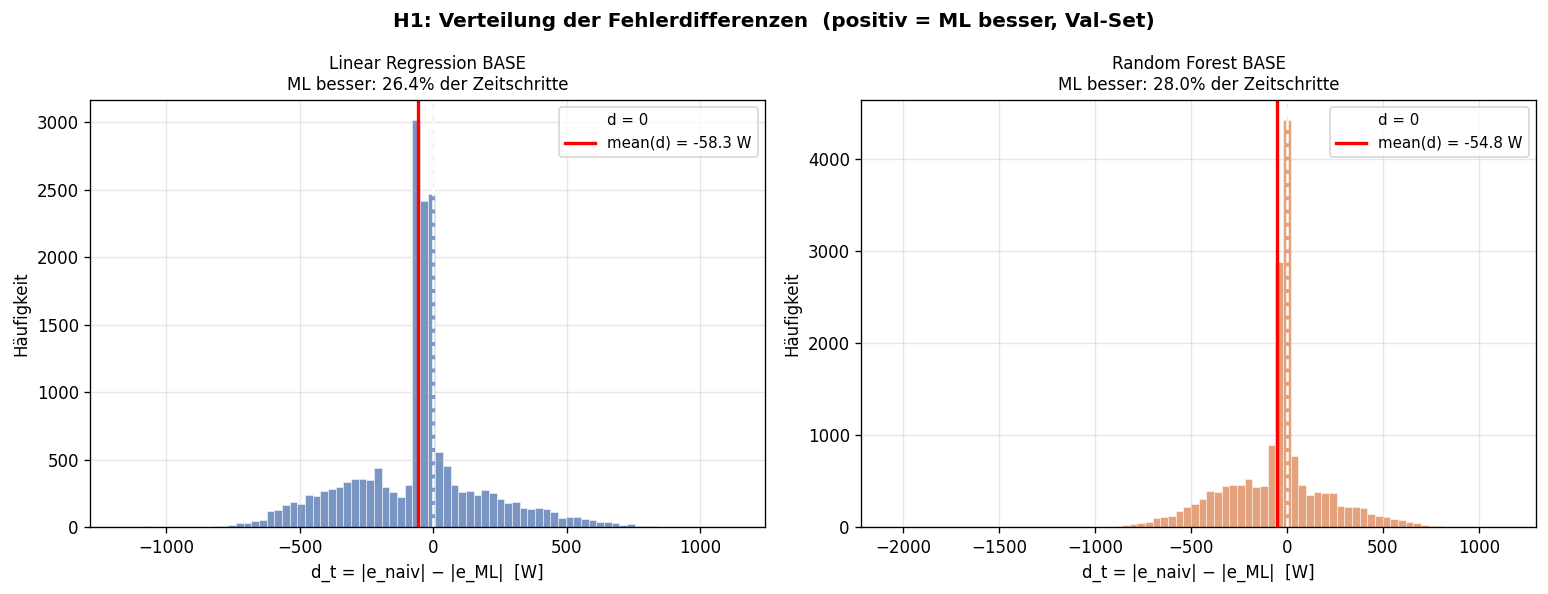

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (model_name, color) in zip(axes, [
    ('Linear Regression BASE', '#4C72B0'),
    ('Random Forest BASE',     '#DD8452'),
]):
    d = diffs[model_name].dropna()
    mean_d = d.mean()
    pct_better = (d > 0).mean() * 100

    ax.hist(d, bins=80, color=color, edgecolor='white', linewidth=0.4, alpha=0.75)
    ax.axvline(0,      color='white', lw=1.5, ls='--', label='d = 0')
    ax.axvline(mean_d, color='red',   lw=2.0, ls='-',
               label=f'mean(d) = {mean_d:+.1f} W')
    ax.set_title(f'{model_name}\nML besser: {pct_better:.1f}% der Zeitschritte', fontsize=10)
    ax.set_xlabel('d_t = |e_naiv| − |e_ML|  [W]')
    ax.set_ylabel('Häufigkeit')
    ax.legend(fontsize=9)

fig.suptitle('H1: Verteilung der Fehlerdifferenzen  (positiv = ML besser, Val-Set)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
SEASON_MAP = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Frühling', 4: 'Frühling', 5: 'Frühling',
              6: 'Sommer', 7: 'Sommer', 8: 'Sommer',
              9: 'Herbst', 10: 'Herbst', 11: 'Herbst'}
SEASON_ORDER = ['Winter', 'Frühling', 'Sommer', 'Herbst']

rows_season = []
for model_name in MODEL_ORDER:
    df = MODEL_DATA[model_name]
    season = df.index.month.map(SEASON_MAP)
    for s in SEASON_ORDER:
        sub = df[season == s]
        if sub.empty:
            continue
        rows_season.append({
            'Jahreszeit': s,
            'Modell':     model_name,
            'MAE [W]':    (sub['y_true'] - sub['y_pred']).abs().mean(),
        })

seasons_present = [s for s in SEASON_ORDER if s in pd.DataFrame(rows_season)['Jahreszeit'].values]
pivot = (pd.DataFrame(rows_season)
         .pivot(index='Jahreszeit', columns='Modell', values='MAE [W]')
         .loc[seasons_present, MODEL_ORDER])   # enforce unified order

display(pivot.round(1))

colors = [MODEL_COLORS[m] for m in MODEL_ORDER]
ax = pivot.plot(kind='bar', figsize=(10, 5), rot=0, color=colors,
                edgecolor='white', linewidth=1.0)
ax.set_title('H1: MAE nach Jahreszeit – Val-Set', fontsize=12, fontweight='bold')
ax.set_ylabel('MAE [W]')
ax.set_xlabel('')
ax.legend(title='Modell', fontsize=9)
for bar in ax.patches:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 2,
                f'{h:.0f}', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

AttributeError: 'dict' object has no attribute 'index'

## 7 · Saisonale Aufschlüsselung (Testset)

Aufschlüsselung nach Jahreszeit zeigt, in welchen Perioden die Wettermodelle
der Naive-Baseline über- oder unterlegen sind.

## 8 · Fazit

### Ergebnis des Paired t-Tests (Testset, α = 0.05)

In [ ]:
print("=" * 70)
print("FAZIT – H1: Naive Baseline vs. Wettermodelle (BASE)")
print("=" * 70)

for model_name in ['Linear Regression BASE', 'Random Forest BASE']:
    row       = ttest_df.loc[model_name]
    confirmed = row[f'H₁ (α={ALPHA})']
    mae_naive = row['MAE naiv [W]']
    mae_ml    = row['MAE ML [W]']
    rmse_naive = row['RMSE naiv [W]']
    rmse_ml    = row['RMSE ML [W]']
    mean_d    = row['mean(d) [W]']
    p         = row['p-Wert (1-s.)']
    delta_pct = (mae_ml - mae_naive) / mae_naive * 100
    verdict   = 'ABGELEHNT ✗' if not confirmed else 'BESTÄTIGT ✓'

    print(f"\n  {model_name}")
    print(f"    MAE:  {mae_naive:.1f} W → {mae_ml:.1f} W  ({delta_pct:+.1f}%)")
    print(f"    RMSE: {rmse_naive:.1f} W → {rmse_ml:.1f} W  (Referenz)")
    print(f"    mean(d_t) = {mean_d:+.1f} W   p = {p:.4f}   → H₁ {verdict}")

print()
print("-" * 70)
print("""
Interpretation:
  H₁ wird für beide BASE-Modelle abgelehnt. Wetterfeatures allein
  (ohne Zeitkontext) reichen nicht aus, um die Naive Baseline zu schlagen.

  Die Naive Baseline nutzt implizit Tageszeit & Saisonalität (saisonale
  Stunden-Mittelwerte) — den dominanten Faktor für PV-Produktion.
  BASE-Modelle ohne Zeitfeatures können diesen Vorteil nicht kompensieren.

  → Ob ML-Modelle die Naive Baseline schlagen, wenn Zeitfeatures
    hinzukommen, wird in H2 untersucht.
""")
print("=" * 70)